In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.feature_extraction import DictVectorizer
from sklearn.linear_model import LogisticRegression

In [2]:
!wget https://raw.githubusercontent.com/DataTalksClub/machine-learning-zoomcamp/main/cohorts/2026/data/course_lead_scoring_2026.csv

--2026-09-11 22:09:49--  https://raw.githubusercontent.com/DataTalksClub/machine-learning-zoomcamp/main/cohorts/2026/data/course_lead_scoring_2026.csv
Loaded CA certificate '/etc/ssl/certs/ca-certificates.crt'
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.109.133, 185.199.111.133, 185.199.108.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.109.133|:443... connected.
HTTP request sent, awaiting response... 416 Range Not Satisfiable

    The file is already fully retrieved; nothing to do.



In [3]:
df = pd.read_csv('course_lead_scoring_2026.csv')

In [4]:
num_f = ['annual_income', 'number_of_courses_viewed', 'interaction_count', 'lead_score']
cat_f = ['lead_source', 'industry', 'employment_status', 'location']

In [5]:
df[num_f] = df[num_f].fillna(0)
df[cat_f] = df[cat_f].fillna('NA')

In [6]:
df_full_train, df_test = train_test_split(df, test_size=0.2, random_state=1)
df_train, df_val = train_test_split(
    df_full_train, test_size=0.25, random_state=1
)

df_train = df_train.reset_index(drop=True)
df_val = df_val.reset_index(drop=True)
df_test = df_test.reset_index(drop=True)

y_train = df_train['converted']
y_val = df_val['converted']
y_test = df_test['converted']

del df_train['converted']
del df_val['converted']
del df_test['converted']

In [7]:
from sklearn.metrics import roc_auc_score

In [8]:
auc_scores = {}

for var in num_f:
    score = df_train[var]
    auc = roc_auc_score(y_train, score)

    if auc < 0.5:
        auc = roc_auc_score(y_train, -score)
    auc_scores[var] = auc

best_var = max(auc_scores, key=auc_scores.get)

for var, auc in sorted(auc_scores.items(), key=lambda x: x[1], reverse=True):
  print(f'{var}: {auc:.4f}')

print(f'\nHighest AUC variable: {best_var}')

lead_score: 0.7882
interaction_count: 0.7649
number_of_courses_viewed: 0.7230
annual_income: 0.6082

Highest AUC variable: lead_score


In [9]:
X_train_num = df_train[num_f].values
scaler = StandardScaler()
X_train_num = scaler.fit_transform(X_train_num)

ohe = OneHotEncoder(sparse_output=False, handle_unknown='ignore')

X_train_cat = df_train[cat_f].values

X_train_cat = ohe.fit_transform(X_train_cat)

X_train = np.column_stack([X_train_num, X_train_cat])

model = LogisticRegression(solver='liblinear', C=1.0, max_iter=1000)
model.fit(X_train, y_train)

,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multiclass` problems (`n_classes >= 3`), all solvers except 'liblinear' minimize the full multinomial loss, 'liblinear' will raise an error.- 'newton-cholesky' is a good choice for `n_samples` >> `n_features * n_classes`, especially with one-hot encoded categorical features with rare categories. Be aware that the memory usage of this solver has a quadratic dependency on `n_features * n_classes` because it explicitly computes the full Hessian matrix.- For small datasets, 'liblinear' is a good choice, whereas 'sag' and 'saga' are faster for large ones;- 'liblinear' can only handle binary classification by default. To apply a one-versus-rest scheme for the multiclass setting one can wrap it with the :class:`~sklearn.multiclass.OneVsRestClassifier`... warning:: The choice of the algorithm depends on the penalty chosen (`l1_ratio=0` for L2-penalty, `l1_ratio=1` for L1-penalty and `0 < l1_ratio < 1` for Elastic-Net) and on (multinomial) multiclass support: ================= ======================== ====================== solver l1_ratio multinomial multiclass ================= ======================== ====================== 'lbfgs' l1_ratio=0 yes 'liblinear' l1_ratio=1 or l1_ratio=0 no 'newton-cg' l1_ratio=0 yes 'newton-cholesky' l1_ratio=0 yes 'sag' l1_ratio=0 yes 'saga' 0<=l1_ratio<=1 yes ================= ======================== ======================.. note:: 'sag' and 'saga' fast convergence is only guaranteed on features with approximately the same scale. You can preprocess the data with a scaler from :mod:`sklearn.preprocessing`... seealso:: Refer to the :ref:`User Guide <Logistic_regression>` for more information regarding :class:`LogisticRegression` and more specifically the :ref:`Table <logistic_regression_solvers>` summarizing solver/penalty supports... versionadded:: 0.17 Stochastic Average Gradient (SAG) descent solver. Multinomial support in version 0.18... versionadded:: 0.19 SAGA solver... versionchanged:: 0.22 The default solver changed from 'liblinear' to 'lbfgs' in 0.22... versionadded:: 1.2 newton-cholesky solver. Multinomial support in version 1.6.",'liblinear'
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalt

In [17]:
X_val_num = df_val[num_f].values
X_val_num = scaler.transform(X_val_num)
X_val_cat = df_val[cat_f].values
X_val_cat = ohe.transform(X_val_cat)

X_val = np.column_stack([X_val_num, X_val_cat])

y_pred = model.predict_proba(X_val)[:,1]

In [18]:
round(roc_auc_score(y_val, y_pred),3)

0.788

In [19]:
thresholds = np.linspace(0,1,101)
thresholds

array([0.  , 0.01, 0.02, 0.03, 0.04, 0.05, 0.06, 0.07, 0.08, 0.09, 0.1 ,
       0.11, 0.12, 0.13, 0.14, 0.15, 0.16, 0.17, 0.18, 0.19, 0.2 , 0.21,
       0.22, 0.23, 0.24, 0.25, 0.26, 0.27, 0.28, 0.29, 0.3 , 0.31, 0.32,
       0.33, 0.34, 0.35, 0.36, 0.37, 0.38, 0.39, 0.4 , 0.41, 0.42, 0.43,
       0.44, 0.45, 0.46, 0.47, 0.48, 0.49, 0.5 , 0.51, 0.52, 0.53, 0.54,
       0.55, 0.56, 0.57, 0.58, 0.59, 0.6 , 0.61, 0.62, 0.63, 0.64, 0.65,
       0.66, 0.67, 0.68, 0.69, 0.7 , 0.71, 0.72, 0.73, 0.74, 0.75, 0.76,
       0.77, 0.78, 0.79, 0.8 , 0.81, 0.82, 0.83, 0.84, 0.85, 0.86, 0.87,
       0.88, 0.89, 0.9 , 0.91, 0.92, 0.93, 0.94, 0.95, 0.96, 0.97, 0.98,
       0.99, 1.  ])

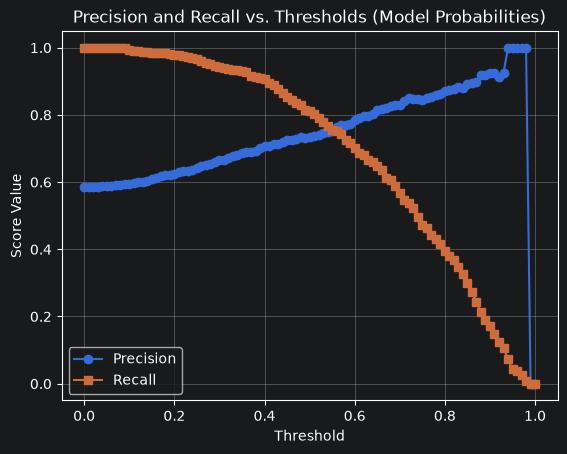

In [23]:
from sklearn.metrics import precision_score, recall_score

precisions, recalls = [], []
scores = model.predict_proba(X_val)[:,1]

for t in thresholds:
    y_pred_t = (scores >= t).astype(int)
    precisions.append(precision_score(y_val, y_pred_t, zero_division=0))
    recalls.append(recall_score(y_val, y_pred_t))

plt.plot(thresholds, precisions, marker='o', label='Precision')
plt.plot(thresholds, recalls, marker='s', label='Recall')
plt.xlabel('Threshold')
plt.ylabel('Score Value')
plt.title('Precision and Recall vs. Thresholds (Model Probabilities)')
plt.legend()
plt.grid(True)
plt.show()


<Axes: >

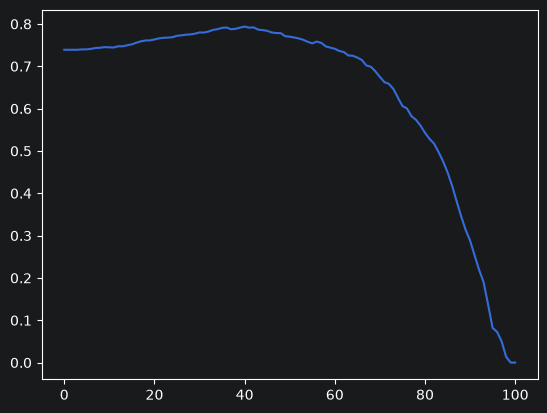

In [24]:
from sklearn.metrics import f1_score

f1_scores=[]
for t in thresholds:
    y_pred_t = (scores>=t).astype(int)
    f1_scores.append(f1_score(y_val, y_pred_t, zero_division=0))

sns.lineplot(f1_scores)

In [25]:
from sklearn.model_selection import KFold

In [27]:
kfold = KFold(n_splits=5, random_state=1, shuffle=True)

In [30]:
scores = []
for train_idx, val_idx in kfold.split(df_full_train):
    df_train = df_full_train.iloc[train_idx]
    df_val = df_full_train.iloc[val_idx]

    y_train = df_train.converted.values
    y_val = df_val.converted.values

    X_train_num = df_train[num_f].values
    scaler = StandardScaler()
    X_train_num = scaler.fit_transform(X_train_num)

    ohe = OneHotEncoder(sparse_output=False, handle_unknown='ignore')

    X_train_cat = df_train[cat_f].values

    X_train_cat = ohe.fit_transform(X_train_cat)

    X_train = np.column_stack([X_train_num, X_train_cat])

    model = LogisticRegression(solver='liblinear', C=1.0, max_iter=1000)
    model.fit(X_train, y_train)

    X_val_num = df_val[num_f].values
    X_val_num = scaler.transform(X_val_num)
    X_val_cat = df_val[cat_f].values
    X_val_cat = ohe.transform(X_val_cat)

    X_val = np.column_stack([X_val_num, X_val_cat])

    y_pred = model.predict_proba(X_val)[:,1]

    auc = roc_auc_score(y_val, y_pred)
    scores.append(auc)

print('%.3f +- %.3f' % (np.mean(scores), np.std(scores)))

0.792 +- 0.013


In [31]:
for C in [0.000001, 0.001, 1]:
    kfold = KFold(n_splits=5, random_state=1, shuffle=True)

    scores = []
    for train_idx, val_idx in kfold.split(df_full_train):
        df_train = df_full_train.iloc[train_idx]
        df_val = df_full_train.iloc[val_idx]

        y_train = df_train.converted.values
        y_val = df_val.converted.values

        X_train_num = df_train[num_f].values
        scaler = StandardScaler()
        X_train_num = scaler.fit_transform(X_train_num)

        ohe = OneHotEncoder(sparse_output=False, handle_unknown='ignore')

        X_train_cat = df_train[cat_f].values

        X_train_cat = ohe.fit_transform(X_train_cat)

        X_train = np.column_stack([X_train_num, X_train_cat])

        model = LogisticRegression(solver='liblinear', C=C, max_iter=1000)
        model.fit(X_train, y_train)

        X_val_num = df_val[num_f].values
        X_val_num = scaler.transform(X_val_num)
        X_val_cat = df_val[cat_f].values
        X_val_cat = ohe.transform(X_val_cat)

        X_val = np.column_stack([X_val_num, X_val_cat])

        y_pred = model.predict_proba(X_val)[:,1]

        auc = roc_auc_score(y_val, y_pred)
        scores.append(auc)

    print('C=%s %.3f +- %.3f' % (C, np.mean(scores), np.std(scores)))

C=1e-06 0.790 +- 0.011
C=0.001 0.791 +- 0.012
C=1 0.792 +- 0.013
